# WMX - Newton Comparison

`01_newton_single_motor_model.ipynb`에서 구현한 Newton 단일 모터 모델에
WMX 로그의 `CMDPOS0`를 입력하고, 생성된 Newton 응답을 WMX Feedback과 비교한다.

현재 이 파일은

- `01_newton_single_motor_model.ipynb`의 단일 모터 모델 불러오기
- WMX Data Log 파일 읽기
- `TIME`, `CMDPOS0`, `FBKPOS0`, `FBKVEL0`, `FBKTRQ0` 추출
- `CMDPOS0`를 Newton 모터의 Command Position으로 입력
- Newton Feedback Position / Velocity와 Motor Torque 생성
- WMX Feedback과 Newton Simulation 결과 비교
- Position / Velocity / Torque 오차 계산

정도로 구성한다.

WMX의 Feedback 값은 Newton Simulation의 입력으로 사용하지 않고,
Newton 결과와 비교하기 위한 기준값(reference)으로 사용한다.

## Newton Single Motor Model 불러오기

앞서 구현한 `01_newton_single_motor_model.ipynb`의 단일 모터 모델을 현재 노트북으로 불러온다.

In [10]:
%run 01_newton_single_motor_model.ipynb

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

## WMX Log 선택

비교에 사용할 WMX Data Log 파일을 지정하고 데이터를 읽는다.

Log의 `TIME` 간격으로 Simulation의 `dt`를 결정하며,
전체 sample 수는 Log에 저장된 데이터 개수에 따라 자동으로 결정된다.

In [12]:
data_file = Path("/home/ireh21/internship/sample_wmx_log.txt")  # 경로 입력. window쪽 경로도 접근 되는지는 확인 필요함.


# 파일 존재 여부 확인
if not data_file.exists():
    raise FileNotFoundError(
        f"WMX3 데이터 파일을 찾을 수 없습니다.\n"
        f"경로: {data_file.resolve()}"
    )


print("✅ WMX3 데이터 파일 선택 완료")
print(f"파일명 : {data_file.name}")
print(f"경로   : {data_file.resolve()}")

✅ WMX3 데이터 파일 선택 완료
파일명 : sample_wmx_log.txt
경로   : /home/ireh21/internship/sample_wmx_log.txt


## WMX Data Log 불러오기

WMX Data Log 파일에서 다음 신호를 읽는다.

- `TIME` : 측정 시간
- `CMDPOS0` : Command Position
- `FBKPOS0` : Feedback Position
- `FBKVEL0` : Feedback Velocity
- `FBKTRQ0` : Feedback Torque

Log 파일의 column 이름을 기준으로 필요한 데이터를 자동으로 추출한다.

In [13]:
def load_wmx_log(file_path):

    # 반드시 필요한 WMX 신호
    required_columns = [
        "TIME",
        "CMDPOS0",
        "FBKPOS0",
        "FBKVEL0",
        "FBKTRQ0",
    ]

    # ------------------------------------------------------------
    # 1. Header 위치 찾기
    # ------------------------------------------------------------

    header_index = None
    column_names = None

    with open(file_path, "r", encoding="utf-8") as f:

        for i, line in enumerate(f):

            columns = line.strip().split()

            # 대소문자 차이를 방지하기 위해 모두 대문자로 변환
            columns_upper = [
                col.upper()
                for col in columns
            ]

            # 필요한 신호들이 모두 들어 있는 줄을 Header로 판단
            if all(
                required in columns_upper
                for required in required_columns
            ):
                header_index = i
                column_names = columns_upper
                break

    if header_index is None:
        raise ValueError(
            "WMX3 Log에서 필요한 Header를 찾을 수 없습니다.\n"
            f"필요한 신호: {required_columns}"
        )

    # ------------------------------------------------------------
    # 2. Header 다음 줄부터 숫자 데이터 읽기
    # ------------------------------------------------------------

    data = np.loadtxt(
        file_path,
        skiprows=header_index + 1,
    )

    # 데이터가 한 줄뿐이어도 2차원 형태 유지
    if data.ndim == 1:
        data = data.reshape(1, -1)

    # ------------------------------------------------------------
    # 3. Column 이름 -> Column 번호 대응
    # ------------------------------------------------------------

    column_index = {
        name: i
        for i, name in enumerate(column_names)
    }

    # ------------------------------------------------------------
    # 4. 필요한 신호를 이름으로 추출
    # ------------------------------------------------------------

    # 합성 WMX 로그의 TIME 단위는 ms
    time_ms = data[
        :, column_index["TIME"]
    ]

    # 시뮬레이션에서 사용하기 위해 초(s)로 변환
    time = time_ms / 1000.0

    command_position = data[
        :, column_index["CMDPOS0"]
    ]

    feedback_position = data[
        :, column_index["FBKPOS0"]
    ]

    feedback_velocity = data[
        :, column_index["FBKVEL0"]
    ]

    feedback_torque = data[
        :, column_index["FBKTRQ0"]
    ]

    # ------------------------------------------------------------
    # 5. 선택적으로 존재하는 신호
    # ------------------------------------------------------------

    cycle = (
        data[:, column_index["CYCLE"]]
        if "CYCLE" in column_index
        else None
    )

    system_time = (
        data[:, column_index["SYSTEM_TIME"]]
        if "SYSTEM_TIME" in column_index
        else None
    )

    # ------------------------------------------------------------
    # 6. 추출한 데이터 반환
    # ------------------------------------------------------------

    return {
        "cycle": cycle,
        "time_ms": time_ms,
        "time": time,
        "system_time": system_time,

        "command_position": command_position,
        "feedback_position": feedback_position,
        "feedback_velocity": feedback_velocity,
        "feedback_torque": feedback_torque,
    }

In [14]:
wmx_data = load_wmx_log(data_file)

# ============================================================
# 데이터 추출 결과 확인
# ============================================================

time = wmx_data["time"]

num_samples = len(time)
start_time = time[0]
end_time = time[-1]
timestamp_span = end_time - start_time

if num_samples >= 2:
    mean_dt = np.mean(np.diff(time))
    sampling_frequency = 1.0 / mean_dt

    # 샘플 하나가 차지하는 시간까지 포함한 전체 기록 길이
    recording_duration = timestamp_span + mean_dt

else:
    mean_dt = None
    sampling_frequency = None
    recording_duration = 0.0


print("WMX3 로그 추출 결과")
print(f"데이터 개수: {num_samples}개")
print(f"시작 시간: {start_time:.6f}초")
print(f"마지막 데이터 시각: {end_time:.6f}초")
print(f"타임스탬프 범위: {timestamp_span:.6f}초")
print(f"전체 기록 길이: {recording_duration:.6f}초")

if mean_dt is not None:
    print(f"평균 샘플 간격: {mean_dt:.6f}초")
    print(f"평균 샘플링 주파수: {sampling_frequency:.2f} Hz")

WMX3 로그 추출 결과
데이터 개수: 4000개
시작 시간: 0.000000초
마지막 데이터 시각: 3.999000초
타임스탬프 범위: 3.999000초
전체 기록 길이: 4.000000초
평균 샘플 간격: 0.001000초
평균 샘플링 주파수: 1000.00 Hz


## WMX Command Position을 이용한 Newton Simulation

WMX Log에서 추출한 `CMDPOS0`를 Newton 단일 모터 모델의 Command Position으로 사용한다.

Newton Simulation의 초기 위치와 초기 속도에는 WMX Log의 첫 번째
Feedback Position과 Feedback Velocity를 적용한다.

`FBKPOS0`, `FBKVEL0`, `FBKTRQ0`는 Simulation 입력이 아니라,
Newton에서 생성된 응답과 비교하기 위한 기준값으로 사용한다.

In [15]:
# 모터 및 제어기 파라미터
params = MotorParams()

# WMX Command Position을 Newton 입력으로 사용
cmd_pos = wmx_data["command_position"]

# WMX 시간 데이터로부터 평균 제어 주기 계산
dt = float(
    np.mean(
        np.diff(wmx_data["time"])
    )
)

# WMX 첫 Feedback을 Newton 초기 상태로 사용
initial_position = float(
    wmx_data["feedback_position"][0]
)

initial_velocity = float(
    wmx_data["feedback_velocity"][0]
)


# Newton Simulation 실행
sim = simulate_motor(
    cmd_pos,
    dt,
    params,

    initial_position=initial_position,
    initial_velocity=initial_velocity,

    device="cpu",
    use_viewer=False,
)


print("✅ Newton Simulation 완료")
print(f"제어 주기 dt       : {dt:.6f} s")
print(f"입력 데이터 개수   : {len(cmd_pos)}개")
print(f"초기 위치          : {initial_position:.6f} rad")
print(f"초기 속도          : {initial_velocity:.6f} rad/s")

Warp CUDA warning: Could not find or load the NVIDIA CUDA driver. GPU execution will not be available.


✅ Newton Simulation 완료
제어 주기 dt       : 0.001000 s
입력 데이터 개수   : 4000개
초기 위치          : 0.000025 rad
초기 속도          : 0.004260 rad/s


## 5. WMX - Newton Response Comparison

동일한 Command Position에 대해 WMX Log의 Feedback과
Newton Simulation에서 계산된 응답을 비교한다.

- Position: Command Position / WMX Feedback / Newton Feedback
- Velocity: WMX Feedback / Newton Feedback
- Torque: WMX Feedback Torque / Newton Motor Torque

현재 비교 결과에 차이가 나는 것은 정상이며,
이후 파라미터 피팅을 통해 그 차이를 줄인다.

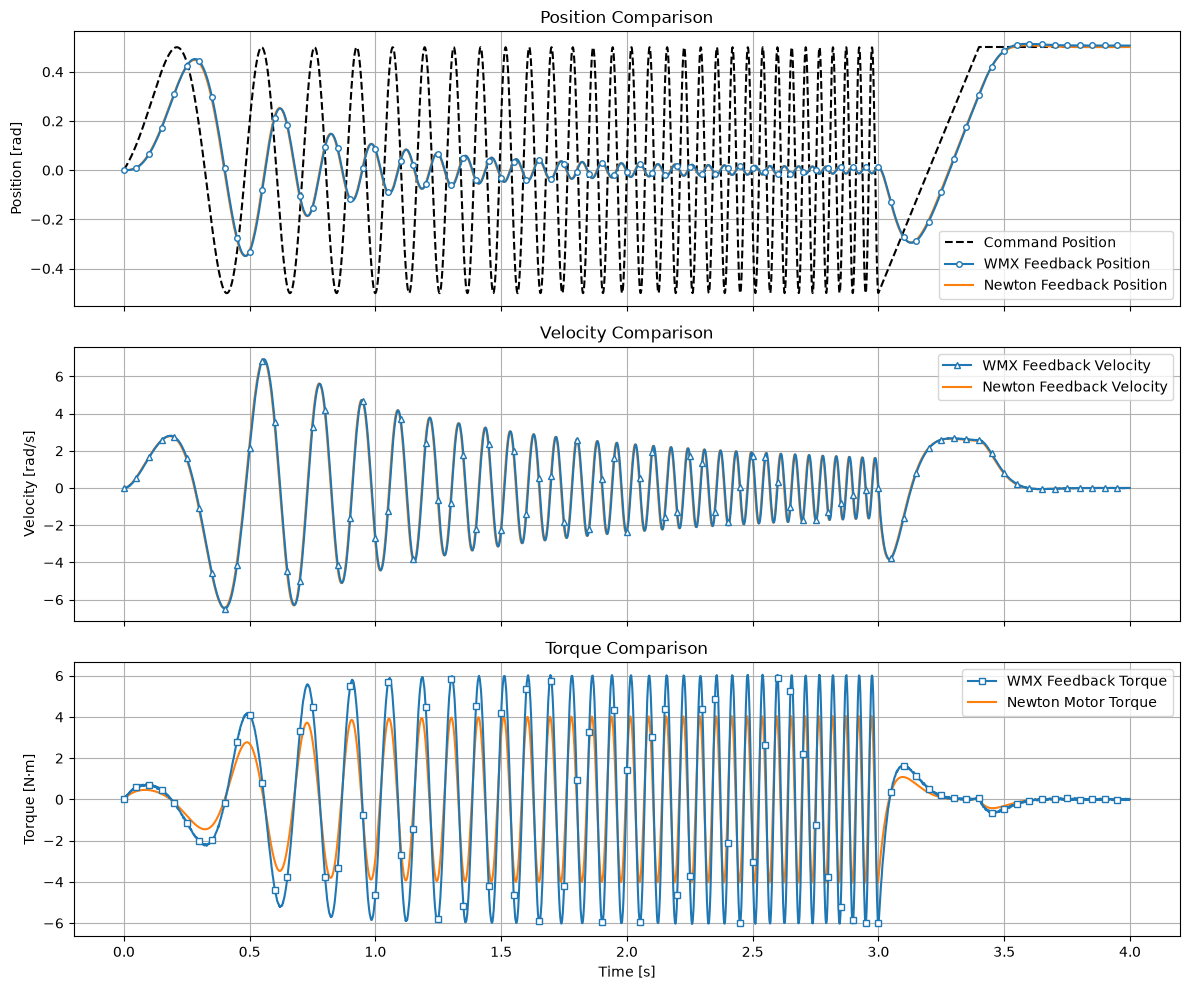

In [17]:
# ------------------------------------------------------------
# 비교에 사용할 시간축
# ------------------------------------------------------------

time = wmx_data["time"]

# 혹시 실제 로그의 시작 시간이 0이 아닐 경우를 대비
time = time - time[0]


# ------------------------------------------------------------
# 데이터 길이 확인
# ------------------------------------------------------------

num_wmx = len(time)
num_sim = len(sim["time"])

if num_wmx != num_sim:
    raise ValueError(
        "WMX 데이터와 Newton Simulation의 길이가 다릅니다.\n"
        f"WMX 데이터 개수: {num_wmx}\n"
        f"Newton 데이터 개수: {num_sim}"
    )


# ------------------------------------------------------------
# WMX - Newton 응답 비교
# ------------------------------------------------------------

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 10),
    sharex=True,
)


# 1. Position 비교
axes[0].plot(
    time,
    wmx_data["command_position"],
    label="Command Position",
    color="black",
    linestyle="--",
)

axes[0].plot(
    time,
    wmx_data["feedback_position"],
    label="WMX Feedback Position",
    color="tab:blue",
    marker="o",              # 원
    markevery=50,
    markersize=4,
    markerfacecolor="white",
    zorder=3,
)

axes[0].plot(
    time,
    sim["feedback_position"],
    label="Newton Feedback Position",
    color="tab:orange",
)

axes[0].set_ylabel("Position [rad]")
axes[0].set_title("Position Comparison")
axes[0].grid(True)
axes[0].legend()


# 2. Velocity 비교
axes[1].plot(
    time,
    wmx_data["feedback_velocity"],
    label="WMX Feedback Velocity",
    color="tab:blue",
    marker="^",              # 삼각형
    markevery=50,
    markersize=5,
    markerfacecolor="white",
    zorder=3,
)

axes[1].plot(
    time,
    sim["feedback_velocity"],
    label="Newton Feedback Velocity",
    color="tab:orange",
)

axes[1].set_ylabel("Velocity [rad/s]")
axes[1].set_title("Velocity Comparison")
axes[1].grid(True)
axes[1].legend()


# 3. Torque 비교
axes[2].plot(
    time,
    wmx_data["feedback_torque"],
    label="WMX Feedback Torque",
    color="tab:blue",
    marker="s",              # 사각형
    markevery=50,
    markersize=4,
    markerfacecolor="white",
    zorder=3,
)

axes[2].plot(
    time,
    sim["feedback_torque"],
    label="Newton Motor Torque",
    color="tab:orange",
)

axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Torque [N·m]")
axes[2].set_title("Torque Comparison")
axes[2].grid(True)
axes[2].legend()


plt.tight_layout()
plt.show()

## 6. WMX - Newton Error Calculation

WMX Feedback을 기준값으로 사용하여 Newton Simulation 결과와의 차이를 계산한다.

Position, Velocity, Torque 각각에 대해 RMSE를 계산하며,
RMSE가 작을수록 Newton Simulation이 WMX Feedback과 유사하다는 의미이다.

각 RMSE는 단위가 서로 다르므로 세 값을 직접 비교하지 않고,
동일한 신호의 파라미터 조정 전후 값을 비교한다.

RMSE(Root Mean Square Error)란, 평균재곱근오차로 **실제값과 시뮬레이션 값이 평균적으로 얼마나 차이나는지**를 나타낸다

In [18]:
# RMSE 함수
def rmse(reference, simulation):

    reference = np.asarray(
        reference,
        dtype=np.float64,
    )

    simulation = np.asarray(
        simulation,
        dtype=np.float64,
    )

    # 데이터 길이 확인
    if reference.shape != simulation.shape:
        raise ValueError(
            "기준 데이터와 Simulation 데이터의 크기가 다릅니다.\n"
            f"Reference shape : {reference.shape}\n"
            f"Simulation shape: {simulation.shape}"
        )

    return float(
        np.sqrt(
            np.mean(
                (reference - simulation) ** 2
            )
        )
    )

In [19]:
# 각 신호의 RMSE 계산
position_rmse = rmse(
    wmx_data["feedback_position"],
    sim["feedback_position"],
)

velocity_rmse = rmse(
    wmx_data["feedback_velocity"],
    sim["feedback_velocity"],
)

torque_rmse = rmse(
    wmx_data["feedback_torque"],
    sim["feedback_torque"],
)


print("WMX - Newton RMSE")
print(f"Position RMSE : {position_rmse:.6f} rad")
print(f"Velocity RMSE : {velocity_rmse:.6f} rad/s")
print(f"Torque RMSE   : {torque_rmse:.6f} N·m")

WMX - Newton RMSE
Position RMSE : 0.005967 rad
Velocity RMSE : 0.230566 rad/s
Torque RMSE   : 1.207180 N·m
